<a href="https://colab.research.google.com/github/sithmi4/Statistical-Learning-e23207/blob/main/Kalman_filter_assignment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kalman Filter Assignment
**Course:** Introduction to Statistical Learning

# Q. Analytical Derivation

Consider the filter model:
\begin{align*}
x_k &= A_{k-1}x_{k-1} + G_{k-1}w_{k-1} \\
y_k &= H_k x_k + z_k
\end{align*}
where $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ and $z_k \sim \mathscr{N}(0, \Sigma_m)$ are mutually independent sequences.

### 1. Show that $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$

Given the state prediction equation:
$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$

Since $x^{+}_{k-1}$ and $w_{k-1}$ are independent Gaussian random vectors where $x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$, any linear combination of them yields a Gaussian random vector.

**Mean ($m_k^-$):**
$$m_k^- = \mathbb{E}[x^{-}_k] = \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}]$$
Using linearity of expectation and noting that $\mathbb{E}[w_{k-1}] = 0$:
$$m_k^- = A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] = A_{k-1}m_{k-1}$$

**Covariance ($P_k^-$):**
$$P_k^- = \text{Var}(x^{-}_k) = \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]$$
$$P_k^- = \mathbb{E}[(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1})(A_{k-1}(x^{+}_{k-1} - m_{k-1}) + G_{k-1}w_{k-1})^T]$$
Expanding this expression and dropping cross-terms due to independence ($\mathbb{E}[(x^{+}_{k-1} - m_{k-1})w_{k-1}^T] = 0$):
$$P_k^- = A_{k-1}\mathbb{E}[(x^{+}_{k-1} - m_{k-1})(x^{+}_{k-1} - m_{k-1})^T]A_{k-1}^T + G_{k-1}\mathbb{E}[w_{k-1}w_{k-1}^T]G_{k-1}^T$$
$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$
Thus, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$. $\quad\blacksquare$

---

### 2. Show that $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$

The measurement equation is given by:
$$y^{-}_k = H_k x^{-}_k + z_k$$
where $z_k \sim \mathscr{N}(0, \Sigma_m)$ is independent of $x^{-}_k$.

**Mean:**
$$\mathbb{E}[y^{-}_k] = \mathbb{E}[H_k x^{-}_k + z_k] = H_k \mathbb{E}[x^{-}_k] + \mathbb{E}[z_k] = H_k m_k^-$$

**Covariance:**
$$\text{Var}(y^{-}_k) = \mathbb{E}[(y^{-}_k - H_k m_k^-)(y^{-}_k - H_k m_k^-)^T]$$
$$\text{Var}(y^{-}_k) = \mathbb{E}[(H_k(x^{-}_k - m_k^-) + z_k)(H_k(x^{-}_k - m_k^-) + z_k)^T]$$
Since $x^{-}_k$ and $z_k$ are independent, cross-terms evaluate to zero:
$$\text{Var}(y^{-}_k) = H_k \mathbb{E}[(x^{-}_k - m_k^-)(x^{-}_k - m_k^-)^T]H_k^T + \mathbb{E}[z_k z_k^T] = H_k P_k^- H_k^T + \Sigma_m$$
Thus, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$. $\quad\blacksquare$

---

### 3. Joint Distribution Expression

To find the joint distribution of $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$, we compute the cross-covariance $\text{Cov}(x_k^-, y_k^-)$:
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T]$$
$$\text{Cov}(x_k^-, y_k^-) = \mathbb{E}[(x_k^- - m_k^-)(x_k^- - m_k^-)^T]H_k^T + \mathbb{E}[(x_k^- - m_k^-)z_k^T]$$
Since $x_k^-$ and $z_k$ are independent, the second term vanishes:
$$\text{Cov}(x_k^-, y_k^-) = P_k^- H_k^T$$
By symmetry, $\text{Cov}(y_k^-, x_k^-) = H_k P_k^-$.
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right). \quad\blacksquare$$

---

### 4. Posterior Update via Multivariate Gaussian Conditioning

Using the standard identity for conditioning a joint Multivariate Gaussian distribution:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left(\begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix}\right)$$
The conditional distribution $(X \mid Y = y)$ is Gaussian with:
$$\mathbb{E}[X \mid Y=y] = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y - \mu_y)$$
$$\text{Var}(X \mid Y=y) = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

Substituting our joint matrix elements ($X = x_k^-$, $Y = y_k^-$, and $y = y^{\mathrm{obs}}_k$):
Let $K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$. Then:
$$m_k = m_k^- + K_k(y^{\mathrm{obs}}_k - H_k m_k^-)$$
$$P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k)P_k^-$$
Thus, $x^{+}_k \sim \mathscr{N}(m_k, P_k)$. $\quad\blacksquare$

---

### 5. Conditional Expectation and Variance
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

### 1. Proof of Predict Step Expressions
$$m_k^- = \mathbb{E}[a x^+_{k-1} + w_{k-1}] = a m_{k-1}$$
$$P_k^- = \text{Var}(a x^+_{k-1} + w_{k-1}) = a^2 P_{k-1} + q. \quad\blacksquare$$

### 2. Proof of Filter Update Expressions
$$m_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$
$$P_k = (1 - K_k h) P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-. \quad\blacksquare$$

### 3. Predictive Measurement Distribution
$$p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr). \quad\blacksquare$$

### 4. Posterior-Predictive Measurement Distribution
$$p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr). \quad\blacksquare$$

In [1]:
# 5. Interactive Animation of 1D Prior and Posterior Transitions
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

a, q, h, r = 1.0, 0.15, 1.0, 0.4
np.random.seed(42)
m, P, num_steps = 0.0, 1.0, 15
history, x_true = [], 0.0

for k in range(num_steps):
    x_true = a * x_true + np.random.normal(0, np.sqrt(q))
    y_obs = h * x_true + np.random.normal(0, np.sqrt(r))
    m_pred = a * m
    P_pred = (a**2) * P + q
    S = (h**2) * P_pred + r
    K = (P_pred * h) / S
    m = m_pred + K * (y_obs - h * m_pred)
    P = (1 - K * h) * P_pred
    history.append((m_pred, P_pred, m, P, y_obs, x_true))

fig, ax = plt.subplots(figsize=(10, 5))
x_domain = np.linspace(-4, 6, 500)
line_pred, = ax.plot([], [], 'r--', label='Predictive State (Prior)', linewidth=2)
line_post, = ax.plot([], [], 'b-', label='Corrected State (Posterior)', linewidth=2)
val_obs = ax.axvline(0, color='g', linestyle=':', label='Sensor Measurement')
val_true = ax.axvline(0, color='black', linestyle='-', label='True State')

ax.set_xlim(-4, 6)
ax.set_ylim(0, 1.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def update_frame(frame):
    m_pred, P_pred, m, P, y_obs, x_t = history[frame]
    line_pred.set_data(x_domain, norm.pdf(x_domain, m_pred, np.sqrt(P_pred)))
    line_post.set_data(x_domain, norm.pdf(x_domain, m, np.sqrt(P)))
    val_obs.set_xdata([y_obs])
    val_true.set_xdata([x_t])
    ax.set_title(f'Iteration Step {frame+1}/{num_steps}')
    return line_pred, line_post, val_obs, val_true

anim = FuncAnimation(fig, update_frame, frames=num_steps, interval=1000, blit=True)
plt.close()
HTML(anim.to_jshtml())

# Q. 2D-Position Estimation

## Part A: Matrix Formulations Derivation
Writing kinematics explicitly as a combined vector system $x_k = A x_{k-1} + G w_{k-1}$:
$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$$
For tracking exclusively position components:
$$y_k = \begin{bmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + z_k$$

## Part B: Python Based GPS Noise Filtering Method

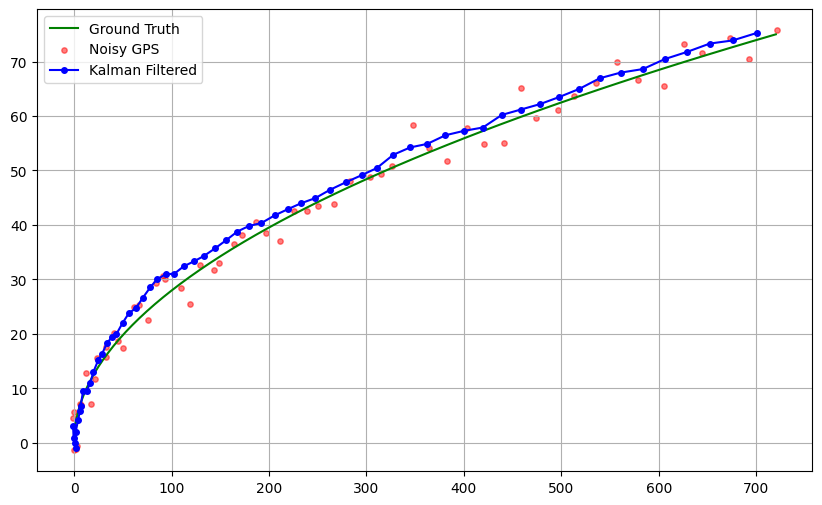

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class KalmanFilter2D:
    def __init__(self, dt, sigma_p_val, sigma_m_val):
        self.dt = dt
        self.A = np.array([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]])
        self.H = np.array([[1,0,0,0],[0,1,0,0]])
        self.G = np.array([[0.5*(dt**2),0],[0,0.5*(dt**2)],[dt,0],[0,dt]])
        self.Q = self.G @ (np.eye(2)*(sigma_p_val**2)) @ self.G.T
        self.R = np.eye(2) * (sigma_m_val**2)
        self.x = np.zeros((4,1))
        self.P = np.eye(4) * 10.0

    def predict(self):
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q

    def update(self, y_meas):
        y = np.array(y_meas).reshape(2,1)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ (y - self.H @ self.x)
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x

dt_step, timesteps, process_error, measurement_error = 0.5, 60, 0.2, 2.5
kf = KalmanFilter2D(dt_step, process_error, measurement_error)
t = np.linspace(0, timesteps*dt_step, timesteps)
true_px, true_py = 0.8*t**2, 2.5*t
measured_x, measured_y, filtered_x, filtered_y = [], [], [], []

for i in range(timesteps):
    mx = true_px[i] + np.random.normal(0, measurement_error)
    my = true_py[i] + np.random.normal(0, measurement_error)
    measured_x.append(mx); measured_y.append(my)
    kf.predict()
    pos = kf.update([mx, my])
    filtered_x.append(pos[0,0]); filtered_y.append(pos[1,0])

plt.figure(figsize=(10, 6))
plt.plot(true_px, true_py, 'g-', label='Ground Truth')
plt.scatter(measured_x, measured_y, color='r', alpha=0.5, s=15, label='Noisy GPS')
plt.plot(filtered_x, filtered_y, 'b-o', markersize=4, label='Kalman Filtered')
plt.legend().set_draggable(True)
plt.grid(True)
plt.show()